# CLick Through Rate Assignment

<br>
Author          :   Phuc Thanh Nguyen
<br>
Created         :   Feb 4th, 2023     
<br>
Last edited     :   Feb 17th, 2023     

## Import libraries and define paths

In [425]:
#--------------------------------------------------------------------------
# Import libraries
#--------------------------------------------------------------------------
import      os
import      numpy                       as      np
import      pandas                      as      pd
import      matplotlib.pyplot           as      plt
import      seaborn                     as      sns
import      category_encoders           as      ce
from        sklearn                     import  metrics
from        sklearn.model_selection     import  train_test_split
from        sklearn.linear_model        import  LogisticRegression
from        sklearn.decomposition       import PCA
from        sklearn.metrics             import  roc_curve, confusion_matrix, precision_score, recall_score, roc_auc_score

In [426]:
#--------------------------------------------------------------------------
# Define paths of data
#--------------------------------------------------------------------------
description_path    =   '/home/ptn/Storage/Learning/Masters/UoA/Course 03:  Introduction to Machine Learning/Module_05_Click_Through_Rate_Prediction_Assignment/data/Data+Description+-+Sheet1 (1).csv'
data_path           =   '/home/ptn/Storage/Learning/Masters/UoA/Course 03:  Introduction to Machine Learning/Module_05_Click_Through_Rate_Prediction_Assignment/data/data (1).csv'

#--------------------------------------------------------------------------
# Define parameters
#--------------------------------------------------------------------------
random_seed         =   1       # I prefer number 1 instead of 42 :v
test_size           =   0.2     # test/total data ratio

## EDA

### Understanding data

#### Data description

In [427]:
#--------------------------------------------------------------------------
# Data description
#--------------------------------------------------------------------------
des_cf = pd.read_csv(description_path)
des_cf

,Variable,Description
0,click:,0/1 for non-click/click
1,"hour: format is YYMMDDHH, so 14091123 means 23...",NaN
2,C1,anonymized categorical variable
3,banner_pos,position of the ad/banner on the page
4,site_id,unique id of the site on which the ad is shown
5,site_domain,unique domain of the site on which the ad is s...
6,site_category,category of the site on which the ad is shown
7,app_id,app id of the site on which the ad is shown
8,app_domain,app category of the site on which the ad is shown
9,app_category,category id of the site on which the ad is shown


<b> click </b> is our target variable

### Data

In [428]:
#--------------------------------------------------------------------------
# Load data
#--------------------------------------------------------------------------
df  =   pd.read_csv(data_path)
print('Shape of data: {}'.format(df.shape))
df.head(5)

Shape of data: (99999, 27)


,click,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,...,C17,C18,C19,C20,C21,month,dayofweek,day,hour,y
0,False,1005,1,856e6d3f,58a89a43,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,...,2528,0,39,100075,221,10,1,28,14,0
1,True,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,...,1934,2,39,-1,16,10,2,22,19,1
2,False,1005,0,e3c09f3a,d262cf1e,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,...,2552,3,167,100202,23,10,3,23,18,0
3,False,1002,0,0da94452,248e439f,50e219e0,ecad2386,7801e8d9,07d7df22,0fa578fd,...,2478,3,167,100074,23,10,2,22,19,0
4,True,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,...,1722,0,35,-1,79,10,1,21,8,1


In [429]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   click             99999 non-null  bool  
 1   C1                99999 non-null  int64 
 2   banner_pos        99999 non-null  int64 
 3   site_id           99999 non-null  object
 4   site_domain       99999 non-null  object
 5   site_category     99999 non-null  object
 6   app_id            99999 non-null  object
 7   app_domain        99999 non-null  object
 8   app_category      99999 non-null  object
 9   device_id         99999 non-null  object
 10  device_ip         99999 non-null  object
 11  device_model      99999 non-null  object
 12  device_type       99999 non-null  int64 
 13  device_conn_type  99999 non-null  int64 
 14  C14               99999 non-null  int64 
 15  C15               99999 non-null  int64 
 16  C16               99999 non-null  int64 
 17  C17         

#### Click and y columns
We saw that Click and y is the same columns, but for more confidence, let check and remove one.

In [430]:
if sum(df['click'] == df['y']) == len(df):
    print('Click and Y is the same columns, just duplicate in data, remove one')
df.drop(['click'], axis=1, inplace=True)
df.head()

Click and Y is the same columns, just duplicate in data, remove one


,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,...,C17,C18,C19,C20,C21,month,dayofweek,day,hour,y
0,1005,1,856e6d3f,58a89a43,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,962c8333,...,2528,0,39,100075,221,10,1,28,14,0
1,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,5b1f94b9,...,1934,2,39,-1,16,10,2,22,19,1
2,1005,0,e3c09f3a,d262cf1e,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,a9a84f4c,...,2552,3,167,100202,23,10,3,23,18,0
3,1002,0,0da94452,248e439f,50e219e0,ecad2386,7801e8d9,07d7df22,0fa578fd,88c62dad,...,2478,3,167,100074,23,10,2,22,19,0
4,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,1e5e0d0e,...,1722,0,35,-1,79,10,1,21,8,1


#### Number of unique values

In [431]:
df.nunique()

C1                      7
banner_pos              7
site_id              1485
site_domain          1331
site_category          19
app_id               1354
app_domain             96
app_category           21
device_id           16801
device_ip           78013
device_model         3145
device_type             4
device_conn_type        4
C14                  1722
C15                     8
C16                     9
C17                   399
C18                     4
C19                    64
C20                   154
C21                    60
month                   1
dayofweek               7
day                    10
hour                   24
y                       2
dtype: int64

In [432]:
df.nunique()/df.shape[0]*100

C1                   0.007000
banner_pos           0.007000
site_id              1.485015
site_domain          1.331013
site_category        0.019000
app_id               1.354014
app_domain           0.096001
app_category         0.021000
device_id           16.801168
device_ip           78.013780
device_model         3.145031
device_type          0.004000
device_conn_type     0.004000
C14                  1.722017
C15                  0.008000
C16                  0.009000
C17                  0.399004
C18                  0.004000
C19                  0.064001
C20                  0.154002
C21                  0.060001
month                0.001000
dayofweek            0.007000
day                  0.010000
hour                 0.024000
y                    0.002000
dtype: float64

We see that some categorical have a lot of unique, however, only 1 month in dataset -> drop month columns

In [433]:
df.drop(['month'], axis=1, inplace=True)
numerical_columns   =   ['hour']
categorical_columns =   ['C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'dayofweek', 'day']

#### High and Low Cardinary features

In [434]:
unique=df[categorical_columns].nunique().sort_values(ascending=True).to_frame()
unique =unique.rename(columns= {0: 'Number of Unique Values'})
unique.index.name = 'Feature'
unique=unique.reset_index()
unique=unique[unique.Feature!='click']
unique

,Feature,Number of Unique Values
0,device_type,4
1,C18,4
2,device_conn_type,4
3,dayofweek,7
4,C1,7
5,banner_pos,7
6,C15,8
7,C16,9
8,day,10
9,site_category,19


In [435]:
# get high cardinality features
high_cardinality_features=unique.loc[(unique['Number of Unique Values'] >= 10)].Feature.unique().tolist()
high_cardinality_features

['day',
 'site_category',
 'app_category',
 'C21',
 'C19',
 'app_domain',
 'C20',
 'C17',
 'site_domain',
 'app_id',
 'site_id',
 'C14',
 'device_model',
 'device_id',
 'device_ip']

In [436]:
# get low cardinality features
low_cardinality_features=unique.loc[(unique['Number of Unique Values'] < 10)].Feature.unique().tolist()
low_cardinality_features

['device_type',
 'C18',
 'device_conn_type',
 'dayofweek',
 'C1',
 'banner_pos',
 'C15',
 'C16']

#### Hour column

In [437]:
df.hour.describe()

count    99999.000000
mean        11.300673
std          5.938725
min          0.000000
25%          7.000000
50%         11.000000
75%         16.000000
max         23.000000
Name: hour, dtype: float64

#### Deal with missing data

In [438]:
#--------------------------------------------------------------------------
# Check missing in row and print
#--------------------------------------------------------------------------
null_data = df[df.isnull().any(axis=1)]
null_data

,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,...,C16,C17,C18,C19,C20,C21,dayofweek,day,hour,y


In [439]:
#--------------------------------------------------------------------------
# Check missing in col and print
#--------------------------------------------------------------------------
df.isnull().sum()

C1                  0
banner_pos          0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_id           0
device_ip           0
device_model        0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
dayofweek           0
day                 0
hour                0
y                   0
dtype: int64

<b> We see that there is no missing value here

#### Class balance?

0    0.830198
1    0.169802
Name: y, dtype: float64




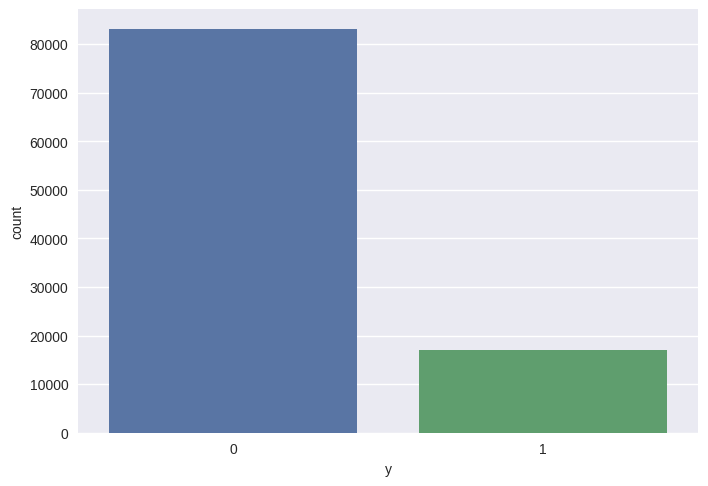

In [440]:
print(df.y.value_counts(normalize = True))
print("\n")
plt.figure()
sns.countplot(x='y', data=df)
plt.show()

We saw that class is imbalance, 87% is 0, only 13% is 1

### Univariate analysis

#### Deal with outliers

In [441]:
#--------------------------------------------------------------------------
# Find outlier function
#--------------------------------------------------------------------------
def find_outlier(df, col_name, plot = True):
    """
        Find outliers of numerical data
        Input:
            .df         :   Dataframe
            .col_name   :   Column name
            .plot       :   Box plot
        Output
            .outliers   :   Outliers in df
    """
    
    
    #--------------------------------------------------------------------------
    # Find outlier part
    #--------------------------------------------------------------------------
    
    df          =   df[col_name]
    q1          =   df.quantile(0.25)
    q3          =   df.quantile(0.75)
    IQR         =   q3-q1
    outliers    =   df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]
    

    #--------------------------------------------------------------------------
    # Plot part
    #--------------------------------------------------------------------------

    plt.boxplot(df)


    return outliers

#### Hour

In [442]:
df['hour'].describe()

count    99999.000000
mean        11.300673
std          5.938725
min          0.000000
25%          7.000000
50%         11.000000
75%         16.000000
max         23.000000
Name: hour, dtype: float64

Series([], Name: hour, dtype: int64)

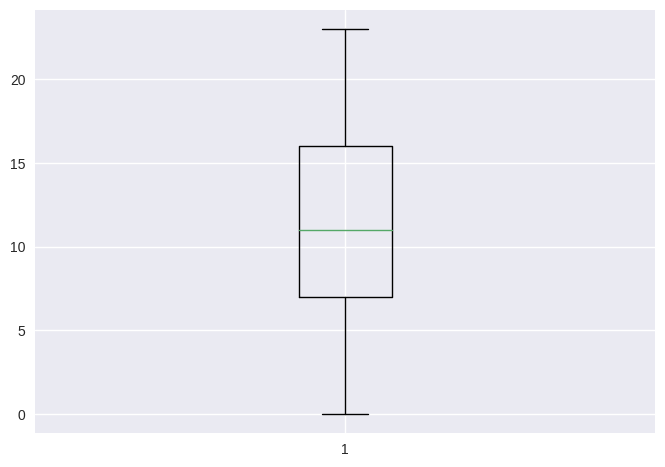

In [443]:
find_outlier(df, 'hour')

No hour is outlier

#### Histogram plot fow low cardinary features

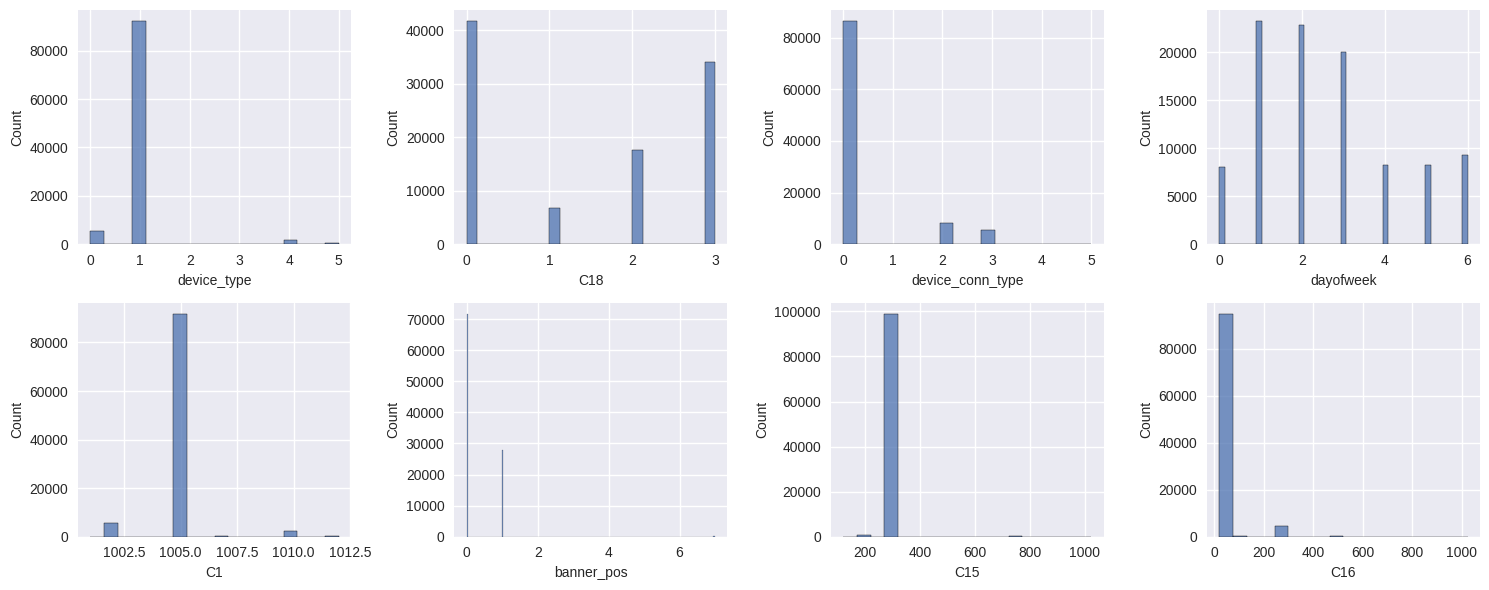

In [444]:
n = 4
# numerical_columns = ['click', 'hour', 'C1', 'banner_pos', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'dayofweek', 'day', 'hour']
numerical_columns = low_cardinality_features
plt.figure(figsize=[15,3*np.math.ceil(len(numerical_columns)/n)])

for i in range(len(numerical_columns)):
    plt.subplot(np.math.ceil(len(numerical_columns)/n),n,i+1)
    sns.histplot(df[numerical_columns[i]])

plt.tight_layout()
plt.show()

### Correlation between features

/tmp/ipykernel_24575/3623245218.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()


Text(0.5, 1.05, 'Pearson correlation of Features')

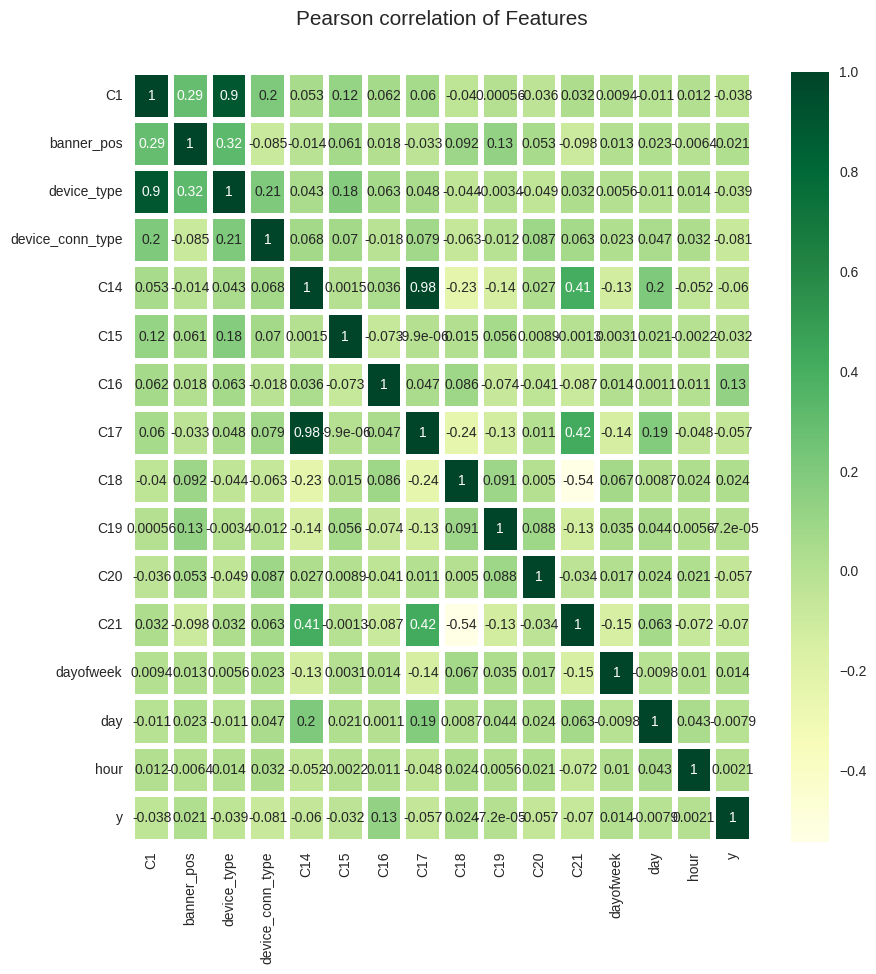

In [445]:
corr = df.corr()
f, ax = plt.subplots(figsize=(10,10))
sns.heatmap(corr, ax=ax, annot=True,linewidths=3,cmap='YlGn')
plt.title("Pearson correlation of Features", y=1.05, size=15)

<b>Observation</b>
<ul>
    <li> C14 and C17 are highly co-related, remove one.
    <li> device type with C1 are highly co-related, remove one.
</ul>

In [446]:
corr_matrix = df.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))

# Find features with correlation greater than 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
print(to_drop)

# Drop features 
df.drop(to_drop, axis=1, inplace=True)


['device_type', 'C17']


/tmp/ipykernel_24575/1005084736.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df.corr().abs()
/tmp/ipykernel_24575/1005084736.py:4: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))


In [447]:
# Also remove columns in low and high cardinary list
low_cardinality_features.remove('device_type')
high_cardinality_features.remove('C17')

In [448]:
# columns after delete high correlated
df.columns

Index(['C1', 'banner_pos', 'site_id', 'site_domain', 'site_category', 'app_id',
       'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model',
       'device_conn_type', 'C14', 'C15', 'C16', 'C18', 'C19', 'C20', 'C21',
       'dayofweek', 'day', 'hour', 'y'],
      dtype='object')

### Data splitting
Split data to train and test

In [449]:
#---------------------------------------------------------------------------------
# Remember to split data before train_test_split to avoid "data leakage" problem
#---------------------------------------------------------------------------------
X                   =   df.drop(['y'], axis=1)
y                   =   df['y']

# Split data
X_train_original,\
X_test_original,\
y_train_original,\
y_test_original     =   train_test_split(X, y, test_size=test_size, random_state=random_seed)


#---------------------------------------------------------------------------------
# Transfrom train data
#---------------------------------------------------------------------------------
X_train_original       =   pd.get_dummies(X_train_original, columns= low_cardinality_features)
dummies_columns        = X_train_original.columns
# Target encoder for high cardinary categorical
target_encoder = ce.TargetEncoder(cols=high_cardinality_features)
X_train_original = target_encoder.fit_transform(X_train_original, y_train_original)


#---------------------------------------------------------------------------------
# Transfrom test data
#---------------------------------------------------------------------------------
X_test_original       =   pd.get_dummies(X_test_original, columns= low_cardinality_features)
X_test_original       =   X_test_original.reindex(columns = dummies_columns, fill_value=0)
X_test_original       =   target_encoder.transform(X_test_original)


In [450]:
X_train_original.head()

,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,C14,...,C15_728,C15_1024,C16_20,C16_36,C16_50,C16_90,C16_250,C16_320,C16_480,C16_768
60153,0.121506,0.126362,0.132479,0.089313,0.143634,0.101369,0.172566,0.147992,0.120952,0.064516,...,0,0,0,0,1,0,0,0,0,0
95459,0.202848,0.202848,0.205945,0.197375,0.194409,0.198396,0.172566,0.209964,0.184086,0.171642,...,0,0,0,0,1,0,0,0,0,0
86944,0.202848,0.202848,0.205945,0.197375,0.194409,0.198396,0.172566,0.145994,0.160379,0.215139,...,0,0,0,0,1,0,0,0,0,0
70925,0.121506,0.126362,0.132479,0.117383,0.112360,0.105869,0.172566,0.147992,0.057007,0.072739,...,0,0,0,0,1,0,0,0,0,0
34616,0.121506,0.126362,0.132479,0.201783,0.194272,0.101369,0.147992,0.169443,0.176653,0.248276,...,0,0,0,0,1,0,0,0,0,0


In [451]:
X_test_original.head()

,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,C14,...,C15_728,C15_1024,C16_20,C16_36,C16_50,C16_90,C16_250,C16_320,C16_480,C16_768
43659,0.202848,0.202848,0.205945,0.197375,0.194409,0.198396,0.172566,0.170127,0.175758,0.193648,...,0,0,0,0,1,0,0,0,0,0
87277,0.114027,0.098206,0.175889,0.197375,0.194409,0.198396,0.172566,0.246825,0.229937,0.143312,...,0,0,0,0,1,0,0,0,0,0
14317,0.202848,0.202848,0.205945,0.197375,0.194409,0.198396,0.172566,0.205055,0.100049,0.189296,...,0,0,0,0,1,0,0,0,0,0
93426,0.202848,0.202848,0.205945,0.197375,0.194409,0.198396,0.172566,0.209964,0.193182,0.156652,...,0,0,0,0,1,0,0,0,0,0
95320,0.121506,0.126362,0.132479,0.028269,0.029463,0.101369,0.172566,0.170127,0.173626,0.072500,...,0,0,0,0,1,0,0,0,0,0


## Model building

### Logistic Regression w/o feature selection

In [452]:
simple_model = LogisticRegression()
simple_model.fit(X_train_original, y_train_original)
print('Train Score:',simple_model.score(X_train_original,y_train_original))
print('Test Score:',simple_model.score(X_test_original,y_test_original))

Train Score: 0.9559994499931249
Test Score: 0.81275


/home/ptn/anaconda3/envs/UoA/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [453]:
y_pred = simple_model.predict(X_test_original)
accuracy = metrics.accuracy_score(y_test_original, y_pred)
print(accuracy)
cnf_matrix = metrics.confusion_matrix(y_test_original, y_pred)
print(cnf_matrix)
# metrics.plot_confusion_matrix(model, X_test, y_test)
# plt.show()
sm_prob = simple_model.predict_proba(X_test_original)
sm_fpr,sm_tpr,_ = roc_curve(y_test_original,sm_prob[:,1])

0.81275
[[16038   592]
 [ 3153   217]]


We saw that model high acc on train, low acc on test -> Overfit

#### Logistic Regression with Auto Feature Selection
Because number feature > 30 => Use auto feature selection 

In [454]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
# #Selecting the Best important features according to Logistic Regression
rfe_selector = RFE(estimator=LogisticRegression(),n_features_to_select = 20, step = 1)
rfe_selector.fit(X_train_original, y_train_original)
X_train_original.columns[rfe_selector.get_support()]

/home/ptn/anaconda3/envs/UoA/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/ptn/anaconda3/envs/UoA/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html

Index(['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain',
       'device_id', 'device_ip', 'device_model', 'C14', 'C19', 'C20', 'C21',
       'C18_1', 'device_conn_type_5', 'C1_1002', 'C1_1007', 'C15_216',
       'C15_728', 'C16_90', 'C16_250'],
      dtype='object')

In [455]:
X_train_original.columns[rfe_selector.get_support()]

Index(['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain',
       'device_id', 'device_ip', 'device_model', 'C14', 'C19', 'C20', 'C21',
       'C18_1', 'device_conn_type_5', 'C1_1002', 'C1_1007', 'C15_216',
       'C15_728', 'C16_90', 'C16_250'],
      dtype='object')

In [456]:
# Get only 20 most importance features to train
new_cols    = X_train_original.columns[rfe_selector.get_support()]
X_train_new = X_train_original[new_cols]
X_test_new  = X_test_original[new_cols]


In [457]:
lr_auto = LogisticRegression()
lr_auto.fit(X_train_new, y_train_original)
print('Train Score:',lr_auto.score(X_train_new,y_train_original))
print('Test Score:',lr_auto.score(X_test_new,y_test_original))

Train Score: 0.9564244553056913
Test Score: 0.8125


In [458]:
y_pred = lr_auto.predict(X_test_new)
accuracy = metrics.accuracy_score(y_test_original, y_pred)
print(accuracy)
cnf_matrix = metrics.confusion_matrix(y_test_original, y_pred)
print(cnf_matrix)
# metrics.plot_confusion_matrix(model, X_test, y_test)
# plt.show()
lr_auto_prob = lr_auto.predict_proba(X_test_new)
lr_auto_fpr,lr_auto_tpr,_ = roc_curve(y_test_original,sm_prob[:,1])

0.8125
[[16029   601]
 [ 3149   221]]


We saw that model not improve so much with auto feature selection

#### PCA

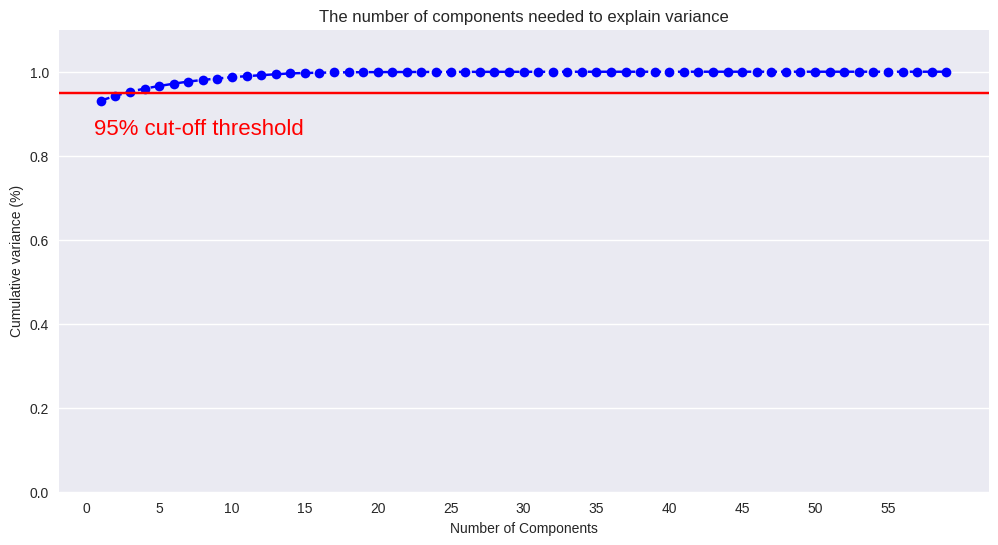

In [459]:
pca = PCA().fit(X_train_original)

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,6)

fig, ax = plt.subplots()
xi = np.arange(1, 60, step=1)
y = np.cumsum(pca.explained_variance_ratio_)

plt.ylim(0.0,1.1)
plt.plot(xi, y, marker='o', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, 60, step=5)) #change from 0-based array index to 1-based human-readable label
plt.ylabel('Cumulative variance (%)')
plt.title('The number of components needed to explain variance')

plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red', fontsize=16)

ax.grid(axis='x')
plt.show()

In [460]:
# Optimal in PCA is 4
X_train_new = pca.transform(X_train_original)[:, :4]
X_test_new = pca.transform(X_test_original)[:, :4]

In [461]:
pca_lr = LogisticRegression()
pca_lr.fit(X_train_new, y_train_original)
print('Train Score:',pca_lr.score(X_train_new,y_train_original))
print('Test Score:',pca_lr.score(X_test_new,y_test_original))

Train Score: 0.8298853735671696
Test Score: 0.8315


In [462]:
y_pred = pca_lr.predict(X_test_new)
accuracy = metrics.accuracy_score(y_test_original, y_pred)
print(accuracy)
cnf_matrix = metrics.confusion_matrix(y_test_original, y_pred)
print(cnf_matrix)
# metrics.plot_confusion_matrix(model, X_test, y_test)
# plt.show()
pca_lr_prob = pca_lr.predict_proba(X_test_new)
pca_lr_fpr,pca_lr_tpr,_ = roc_curve(y_test_original,sm_prob[:,1])

0.8315
[[16630     0]
 [ 3370     0]]


With PCA, Model better a liile bit, but loose the interpretability

### Decision Tree

In [463]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth = 10)
tree.fit(X_train_original,y_train_original)
print('Train Score:',tree.score(X_train_original,y_train_original))
print('Test Score:',tree.score(X_test_original,y_test_original))

Train Score: 0.9662120776509706
Test Score: 0.8082


In [464]:
y_score = tree.predict_proba(X_test_original)
fpr, tpr, thresholds = roc_curve(y_test_original, y_score[:, 1])
roc_auc_score = roc_auc_score(y_test_original,y_score[:,1])
print(roc_auc_score)

0.6040830985437993


In [465]:
y_pred = tree.predict(X_test_original)
precision = precision_score(y_test_original, y_pred, average = 'weighted')
recall = recall_score(y_test_original, y_pred, average = 'weighted')
print("Precision: %s, Recall: %s" %(precision, recall))

Precision: 0.7581421512713611, Recall: 0.8082


In [466]:
matrix = confusion_matrix(y_test_original,y_pred)
tn, fp, fn, tp = matrix.ravel()
print(matrix)

[[15694   936]
 [ 2900   470]]


In [467]:
for max_depth_val in [2, 3, 5, 10, 15, 20]:
    clf = DecisionTreeClassifier(max_depth = max_depth_val)
    print("Evaluating tree with max_depth = %s" %(max_depth_val))
    y_pred = tree.fit(X_train_original,y_train_original).predict(X_test_original) 
    print("Confusion matrix: ")
    print(confusion_matrix(y_test_original, y_pred))
    prec = precision_score(y_test_original, y_pred, average = 'weighted')
    recall = recall_score(y_test_original, y_pred, average = 'weighted')
    print("Precision: %s, Recall: %s" %(prec, recall))

Evaluating tree with max_depth = 2
Confusion matrix: 
[[15691   939]
 [ 2898   472]]
Precision: 0.7582359708284077, Recall: 0.80815
Evaluating tree with max_depth = 3
Confusion matrix: 
[[15698   932]
 [ 2896   474]]
Precision: 0.7588004002881977, Recall: 0.8086
Evaluating tree with max_depth = 5
Confusion matrix: 
[[15688   942]
 [ 2894   476]]
Precision: 0.7585631949811448, Recall: 0.8082
Evaluating tree with max_depth = 10
Confusion matrix: 
[[15694   936]
 [ 2896   474]]
Precision: 0.7586113833793048, Recall: 0.8084
Evaluating tree with max_depth = 15
Confusion matrix: 
[[15696   934]
 [ 2897   473]]
Precision: 0.7585885818007565, Recall: 0.80845
Evaluating tree with max_depth = 20
Confusion matrix: 
[[15694   936]
 [ 2900   470]]
Precision: 0.7581421512713611, Recall: 0.8082


In [468]:
from sklearn.model_selection import KFold,cross_val_score
for max_depth_val in [3, 5, 10]:
    k_fold = KFold(n_splits = 4)
    clf = DecisionTreeClassifier(max_depth = max_depth_val)
    print("Evaluating Decision Tree for max_depth = %s" %(max_depth_val))
    y_pred = tree.fit(X_train_original, y_train_original).predict(X_test_original) 
  
    cv_precision = cross_val_score(clf, X_train_original, y_train_original, cv = k_fold, scoring = 'recall_weighted')
    precision = recall_score(y_test_original, y_pred, average = 'weighted')
    print("Cross validation Recall: %s" %(cv_precision.mean()))
    print("Test Recall: %s" %(precision.mean()))

Evaluating Decision Tree for max_depth = 3
Cross validation Recall: 0.9595619874743737
Test Recall: 0.80825
Evaluating Decision Tree for max_depth = 5
Cross validation Recall: 0.9607870156007801
Test Recall: 0.80825
Evaluating Decision Tree for max_depth = 10
Cross validation Recall: 0.9615370181009051
Test Recall: 0.8083


### Random Forest

In [469]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'bootstrap': [True],
    'max_depth': [5,10, 15], 
    'n_estimators':[2,5,10,20,50],
    'min_samples_split': [2, 3, 4],
    'max_features' : ['log2']
}

rf = RandomForestClassifier(random_state=42)

rf_search = RandomizedSearchCV(estimator = rf, param_distributions=param_grid, 
                          cv = 5, n_jobs = -1, verbose = 2, n_iter = 10)

model = rf_search.fit(X_train_original,y_train_original)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_split=3, n_estimators=5; total time=   0.3s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_split=3, n_estimators=5; total time=   0.3s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_split=3, n_estimators=5; total time=   0.3s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_split=3, n_estimators=5; total time=   0.3s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_split=3, n_estimators=5; total time=   0.4s
[CV] END bootstrap=True, max_depth=5, max_features=log2, min_samples_split=3, n_estimators=50; total time=   1.3s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_split=3, n_estimators=10; total time=   0.6s
[CV] END bootstrap=True, max_depth=5, max_features=log2, min_samples_split=3, n_estimators=50; total time=   1.4s
[CV] END bootstrap=True, m

In [470]:
rf_search.best_params_

{'n_estimators': 50,
 'min_samples_split': 3,
 'max_features': 'log2',
 'max_depth': 10,
 'bootstrap': True}

In [471]:
clf_rf = RandomForestClassifier(n_estimators= 20,
 min_samples_split= 2,
 max_features= 'log2',
 max_depth= 10,
 bootstrap= True,
 random_state=42)
clf_rf.fit(X_train_original,y_train_original)

RandomForestClassifier(max_depth=10, max_features='log2', n_estimators=20,
                       random_state=42)

In [472]:
y_test_pred = clf_rf.predict(X_test_original)

print(confusion_matrix(y_test_original, y_test_pred))
prec = precision_score(y_test_original, y_test_pred, average = 'weighted')
recall = recall_score(y_test_original, y_test_pred, average = 'weighted')
print("Precision: %s, Recall: %s" %(prec, recall))

[[16289   341]
 [ 3225   145]]
Precision: 0.7443539855948098, Recall: 0.8217


In [473]:
rf_prob = clf_rf.predict_proba(X_test_original)
rf_fpr,rf_tpr,_ = roc_curve(y_test_original,rf_prob[:,1])

RF help us a little bit on overfit problem, but still very high variance

### XGBoost

In [474]:
import xgboost as xgb
from sklearn.metrics import roc_curve,auc,confusion_matrix,precision_score,recall_score,roc_auc_score
params = {
    "objective": "binary:logistic",
    "booster" : "gbtree",
    "eval_metric": "logloss",
    "eta":0.1,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "silent": 1,
}
xgclf=xgb.XGBClassifier(**params)
xgclf.fit(X_train_original, y_train_original,
        eval_set=[(X_test_original, y_test_original)],
        verbose=False)
xgpred=xgclf.predict_proba(X_test_original)

[01:11:17] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1667849645640/work/src/learner.cc:767: 
Parameters: { "silent" } are not used.



In [475]:
from sklearn import metrics 
#y_score = xgclf.predict_proba(x_test)
#fpr, tpr, thresholds = roc_curve(y_test, y_score[:, 1])
roc_auc_score = metrics.roc_auc_score(y_test_original,xgpred[:,1])
print(roc_auc_score)
print(xgclf.score(X_test_original,y_test_original))
xgb_fpr,xgb_tpr,_ = roc_curve(y_test_original,xgpred[:,1])


0.6453893521236335
0.8155


In [476]:
random_probs = [0 for i in range(len(y_test_original))]
p_fpr, p_tpr, _ = roc_curve(y_test_original, random_probs, pos_label=1)

/tmp/ipykernel_24575/3209096116.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


Text(0.5, 1.0, 'AUC-ROC Curve')

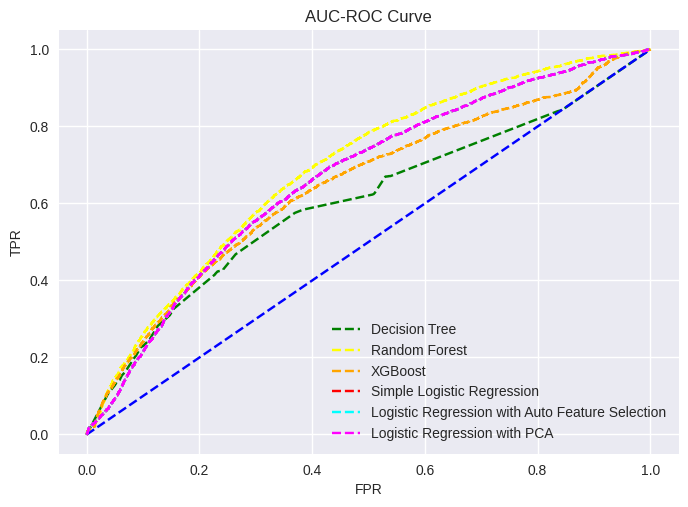

In [477]:
plt.style.use('seaborn')
plt.plot(fpr,tpr,linestyle = '--',color = 'green',label='Decision Tree')
plt.plot(rf_fpr,rf_tpr,linestyle = '--',color = 'yellow',label='Random Forest')
plt.plot(xgb_fpr,xgb_tpr,linestyle = '--',color = 'orange',label='XGBoost')
plt.plot(p_fpr,p_tpr,linestyle='--',color = 'blue')
plt.plot(sm_fpr,sm_tpr,linestyle='--',color = 'red', label='Simple Logistic Regression')
plt.plot(lr_auto_fpr,lr_auto_tpr,linestyle='--',color = 'cyan', label='Logistic Regression with Auto Feature Selection')
plt.plot(pca_lr_fpr,pca_lr_tpr,linestyle='--',color = 'magenta', label='Logistic Regression with PCA')
plt.legend()
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('AUC-ROC Curve')

With the ROC Curve: we can choose 3 model:
<ul>
    <li> Random Forest, which have highest ROC Curve on test data
    <li> Logistic Regession with PCA, have second highest AUROC
    <li> Losgistic Regression with high enough AUROC, can better to interpret than 2 others
</ul>